# Speech Emotion Recognition Using CNN 

This notebook implements a complete Speech Emotion Recognition (SER) pipeline using a Convolutional Neural Network (CNN). It covers data loading, preprocessing, feature extraction, model training, and evaluation.

Key steps include:
- Loading and parsing four benchmark audio emotion datasets
- Exploratory visualization of audio signals and features
- Data augmentation to improve model generalization
- Extracting ZCR, RMS Energy, and MFCC features
- Training a CNN model for emotion classification
- Evaluating performance using accuracy, confusion matrix, and classification report

**Datasets used:** RAVDESS · CREMA-D · TESS · SAVEE  
**Target emotions:** neutral, happy, sad, angry, fear, disgust, surprise

## 1. Import Libraries

In [ ]:
import os
import sys
import warnings
import timeit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import (
    Dense, Flatten, Dropout, Activation,
    Conv1D, MaxPooling1D, AveragePooling1D,
    LSTM, GRU, BatchNormalization,
    Input, Embedding
)
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import IPython.display as ipd
from tqdm import tqdm
warnings.filterwarnings("ignore")

## 2. Dataset Paths

In [4]:
RAVDESS = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/"
CREMA   = "/kaggle/input/datasets/ejlok1/cremad/AudioWAV/"
TESS    = "/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/"
SAVEE   = "/kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/ALL/"

## 3. Load & Label Each Dataset

Each dataset encodes emotion differently in its filenames. The cells below parse each convention and produce a unified `(Emotions, Path)` DataFrame.

### 3.1 RAVDESS
Filename format: `XX-XX-{emotion}-...wav`  
The **third** hyphen-separated token is an integer emotion code (1–8).

In [5]:
import os
import pandas as pd

file_emotion = []
file_path = []

for actor_dir in os.listdir(RAVDESS):
    
    actor_path = os.path.join(RAVDESS, actor_dir)
    
    # skip if not directory
    if not os.path.isdir(actor_path):
        continue

    for fname in os.listdir(actor_path):
        
        # skip non-audio files
        if not fname.endswith(".wav"):
            continue
        
        parts = fname.split("-")
        
        # safety check
        if len(parts) < 3:
            continue
        
        try:
            emotion_code = int(parts[2])
        except:
            continue
        
        file_emotion.append(emotion_code)
        file_path.append(os.path.join(actor_path, fname))


# DataFrame
ravdess_df = pd.DataFrame({
    "Emotions": file_emotion,
    "Path": file_path
})

# Mapping
ravdess_df["Emotions"] = ravdess_df["Emotions"].replace({
    1:"neutral", 2:"neutral", 3:"happy", 4:"sad",
    5:"angry",   6:"fear",    7:"disgust", 8:"surprise"
})

# Output
print("Total files:", len(ravdess_df))
print(ravdess_df["Emotions"].value_counts())
ravdess_df.head()

Total files: 1440
Emotions
neutral     288
surprise    192
disgust     192
fear        192
sad         192
happy       192
angry       192
Name: count, dtype: int64


,Emotions,Path
0,surprise,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
1,neutral,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
2,disgust,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
3,disgust,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
4,neutral,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...


### 3.2 CREMA-D
Filename format: `{ID}_{text}_{EMOTION}_{level}.wav`  
Emotion is the **third** underscore-separated token (e.g., `ANG`, `HAP`).

In [6]:
CREMA_EMOTION_MAP = {
    "SAD": "sad", "ANG": "angry", "DIS": "disgust",
    "FEA": "fear", "HAP": "happy", "NEU": "neutral"
}

file_emotion, file_path = [], []
for fname in os.listdir(CREMA):
    token = fname.split("_")[2]
    file_emotion.append(CREMA_EMOTION_MAP.get(token, "unknown"))
    file_path.append(os.path.join(CREMA, fname))

crema_df = pd.DataFrame({"Emotions": file_emotion, "Path": file_path})
print(crema_df["Emotions"].value_counts())
crema_df.head()

Emotions
disgust    1271
happy      1271
sad        1271
fear       1271
angry      1271
neutral    1087
Name: count, dtype: int64


,Emotions,Path
0,disgust,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...
1,happy,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...
2,happy,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...
3,disgust,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...
4,disgust,/kaggle/input/datasets/ejlok1/cremad/AudioWAV/...


### 3.3 TESS
Files are organised in per-emotion sub-folders. Filename format: `{word}_{emotion}.wav`  
The tag `ps` maps to *surprise*.

In [7]:
file_emotion, file_path = [], []
for subdir in os.listdir(TESS):
    for fname in os.listdir(os.path.join(TESS, subdir)):
        tag = fname.split(".")[0].split("_")[2]
        file_emotion.append("surprise" if tag == "ps" else tag)
        file_path.append(os.path.join(TESS, subdir, fname))

tess_df = pd.DataFrame({"Emotions": file_emotion, "Path": file_path})
print(tess_df["Emotions"].value_counts())
tess_df.head()

Emotions
fear        400
angry       400
disgust     400
neutral     400
sad         400
surprise    400
happy       400
Name: count, dtype: int64


,Emotions,Path
0,fear,/kaggle/input/datasets/ejlok1/toronto-emotiona...
1,fear,/kaggle/input/datasets/ejlok1/toronto-emotiona...
2,fear,/kaggle/input/datasets/ejlok1/toronto-emotiona...
3,fear,/kaggle/input/datasets/ejlok1/toronto-emotiona...
4,fear,/kaggle/input/datasets/ejlok1/toronto-emotiona...


### 3.4 SAVEE
Filename format: `{speaker}_{prefix}{index}.wav`  
The prefix encodes emotion (e.g., `a`→angry, `sa`→sad, `su`→surprise).

In [8]:
SAVEE_EMOTION_MAP = {
    "a": "angry", "d": "disgust", "f": "fear",
    "h": "happy", "n": "neutral", "sa": "sad", "su": "surprise"
}

file_emotion, file_path = [], []
for fname in os.listdir(SAVEE):
    # prefix sits between the underscore and the trailing digits+extension
    prefix = fname.split("_")[1][:-6]
    file_emotion.append(SAVEE_EMOTION_MAP.get(prefix, "unknown"))
    file_path.append(os.path.join(SAVEE, fname))

savee_df = pd.DataFrame({"Emotions": file_emotion, "Path": file_path})
print(savee_df["Emotions"].value_counts())
savee_df.head()

Emotions
neutral     120
fear         60
happy        60
disgust      60
angry        60
surprise     60
sad          60
Name: count, dtype: int64


,Emotions,Path
0,happy,/kaggle/input/datasets/ejlok1/surrey-audiovisu...
1,fear,/kaggle/input/datasets/ejlok1/surrey-audiovisu...
2,happy,/kaggle/input/datasets/ejlok1/surrey-audiovisu...
3,disgust,/kaggle/input/datasets/ejlok1/surrey-audiovisu...
4,angry,/kaggle/input/datasets/ejlok1/surrey-audiovisu...


### 3.5 Merge All Datasets

In [9]:
data_path = pd.concat([ravdess_df, crema_df, tess_df, savee_df], axis=0).reset_index(drop=True)
print(f"Total samples: {len(data_path)}")
print(data_path["Emotions"].value_counts())
data_path.head()

Total samples: 12162
Emotions
disgust     1923
sad         1923
fear        1923
happy       1923
angry       1923
neutral     1895
surprise     652
Name: count, dtype: int64


,Emotions,Path
0,surprise,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
1,neutral,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
2,disgust,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
3,disgust,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
4,neutral,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...


## 4. Audio Visualization
Load a sample clip and inspect its time-domain waveform, Mel spectrogram, and MFCCs.

In [10]:
sample_path = data_path["Path"].iloc[0]
data, sr = librosa.load(sample_path)
print(f"Sample rate: {sr} Hz | Duration: {len(data)/sr:.2f} s")
ipd.Audio(data, rate=sr)

Sample rate: 22050 Hz | Duration: 3.54 s


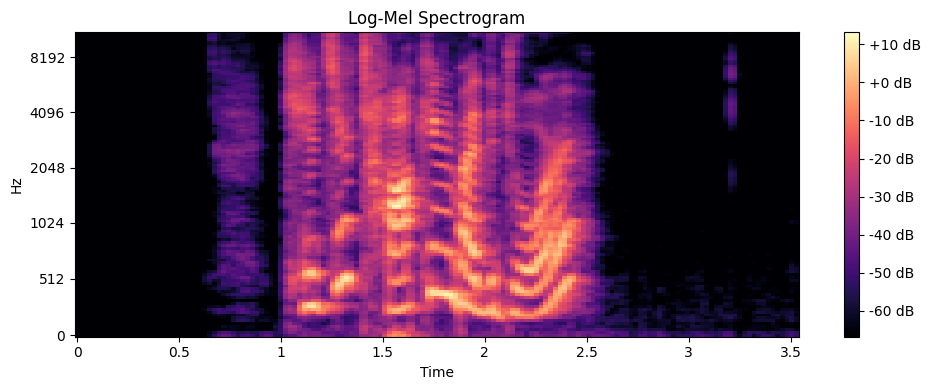

In [11]:
# Log-Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128, fmax=8000)
log_mel  = librosa.power_to_db(mel_spec)

plt.figure(figsize=(10, 4))
librosa.display.specshow(log_mel, sr=sr, x_axis="time", y_axis="mel")
plt.title("Log-Mel Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()

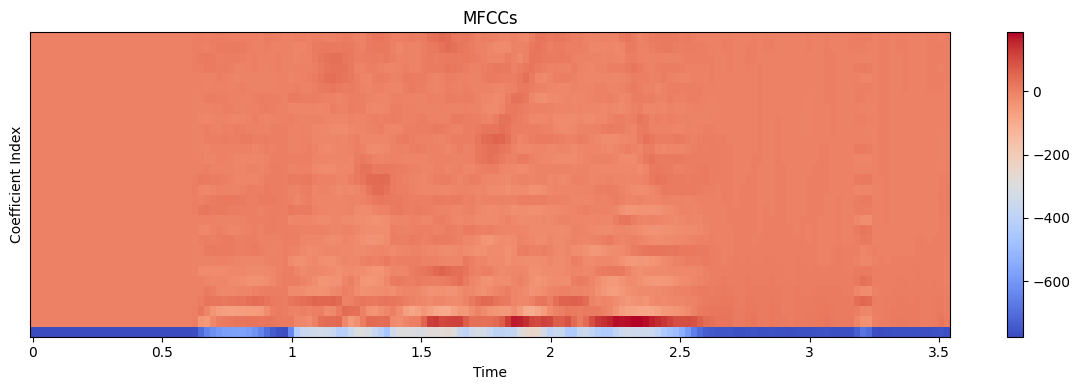

In [12]:
# First 30 MFCC coefficients
mfcc_feat = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=30)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc_feat, sr=sr, x_axis="time")
plt.title("MFCCs")
plt.ylabel("Coefficient Index")
plt.colorbar()
plt.tight_layout()
plt.show()

## 5. Data Augmentation
Applying four transformations to each clip quadruples the effective dataset size and improves generalization:
| Technique | Effect |
|-----------|--------|
| Gaussian noise | Simulates recording imperfections |
| Time stretch | Alters speaking rate without changing pitch |
| Time shift | Offsets the signal along the time axis |
| Pitch shift | Raises or lowers perceived vocal pitch |

In [13]:
def add_noise(data):
    """Add scaled Gaussian noise to a waveform."""
    amplitude = 0.035 * np.random.uniform() * np.amax(data)
    return data + amplitude * np.random.normal(size=data.shape[0])

def time_stretch(data, rate=0.8):
    """Stretch audio duration without altering pitch."""
    return librosa.effects.time_stretch(y=data, rate=rate)

def time_shift(data):
    """Randomly shift audio along the time axis."""
    shift = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift)

def pitch_shift(data, sr, n_steps=0.7):
    """Shift pitch by n_steps semitones."""
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps)

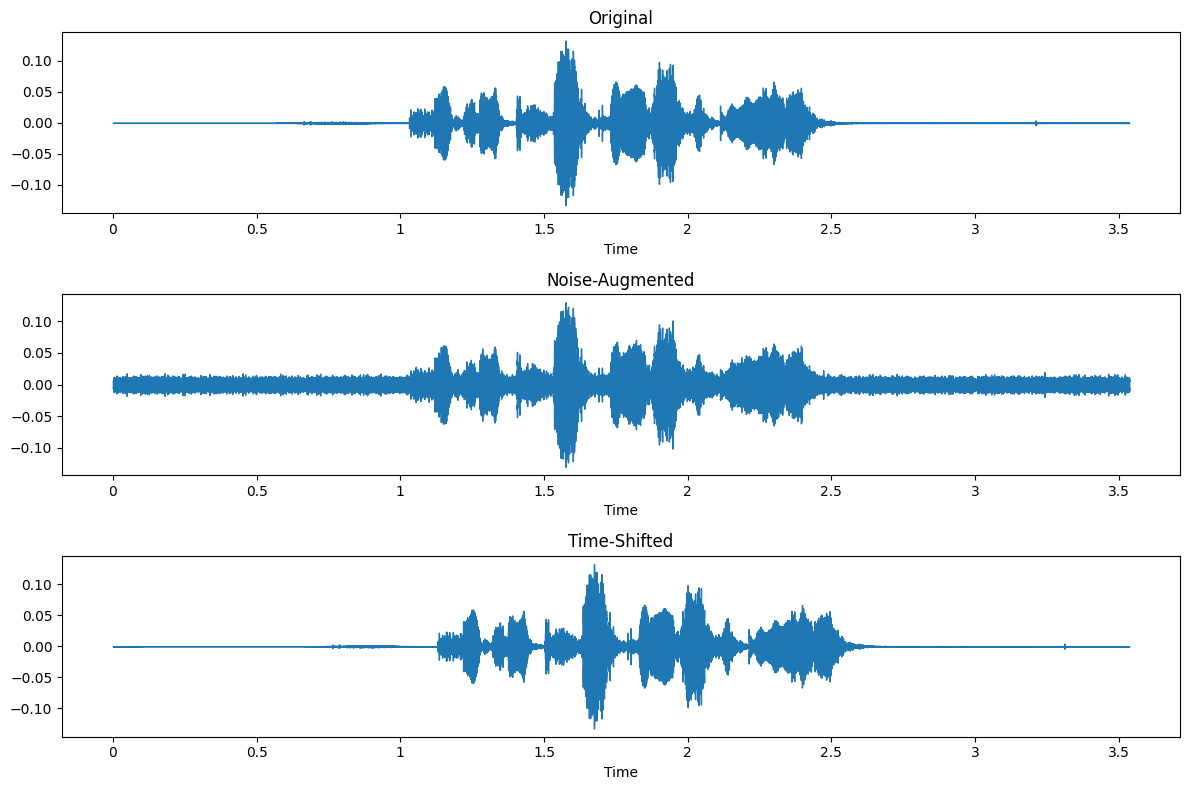

In [14]:
# Visual comparison of augmentation effects
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

librosa.display.waveshow(data, sr=sr, ax=axes[0])
axes[0].set_title("Original")

librosa.display.waveshow(add_noise(data), sr=sr, ax=axes[1])
axes[1].set_title("Noise-Augmented")

librosa.display.waveshow(time_shift(data), sr=sr, ax=axes[2])
axes[2].set_title("Time-Shifted")

plt.tight_layout()
plt.show()

## 6. Feature Extraction
Three feature types are computed per frame and concatenated into a single vector:
- **ZCR** — Zero Crossing Rate (captures signal noisiness / voicing)
- **RMS Energy** — Root Mean Square Energy (proxy for loudness dynamics)
- **MFCCs** — Mel-Frequency Cepstral Coefficients (compact spectral envelope)

In [15]:
def compute_zcr(data, frame_length=2048, hop_length=512):
    return np.squeeze(librosa.feature.zero_crossing_rate(
        data, frame_length=frame_length, hop_length=hop_length))

def compute_rms(data, frame_length=2048, hop_length=512):
    return np.squeeze(librosa.feature.rms(
        y=data, frame_length=frame_length, hop_length=hop_length))

def compute_mfcc(data, sr, frame_length=2048, hop_length=512, flatten=True):
    coeffs = librosa.feature.mfcc(y=data, sr=sr, n_fft=frame_length, hop_length=hop_length)
    return np.ravel(coeffs.T) if flatten else np.squeeze(coeffs.T)

def extract_features(data, sr=22050, frame_length=2048, hop_length=512):
    """Concatenate ZCR, RMS, and MFCC into a single flat feature vector."""
    return np.hstack([
        compute_zcr(data, frame_length, hop_length),
        compute_rms(data, frame_length, hop_length),
        compute_mfcc(data, sr, frame_length, hop_length)
    ])

def get_features(path, duration=2.5, offset=0.6):
    """
    Load an audio clip and return a (4, n_features) matrix covering:
    original | noise-augmented | pitch-shifted | pitch-shifted + noise
    """
    data, sr = librosa.load(path, duration=duration, offset=offset)
    pitched  = pitch_shift(data, sr)

    return np.vstack([
        extract_features(data, sr),
        extract_features(add_noise(data), sr),
        extract_features(pitched, sr),
        extract_features(add_noise(pitched), sr),
    ])

## 7. Run Extraction

In [16]:
import multiprocessing as mp
print(f"CPU cores available: {mp.cpu_count()}")

CPU cores available: 4


In [17]:
start = timeit.default_timer()
X, Y = [], []

for idx, (path, emotion) in enumerate(
        tqdm(zip(data_path["Path"], data_path["Emotions"]), total=len(data_path))):
    for feat_vec in get_features(path):
        X.append(feat_vec)
        Y.append(emotion)
    if idx % 500 == 0:
        print(f"  {idx}/{len(data_path)} files processed")

elapsed = timeit.default_timer() - start
print(f"\nComplete — {len(X)} samples | {elapsed:.1f}s elapsed")

  0%|          | 2/12162 [00:01<2:13:49,  1.51it/s]

  0/12162 files processed


  4%|▍         | 502/12162 [01:02<23:55,  8.12it/s]

  500/12162 files processed


  8%|▊         | 1002/12162 [02:03<22:46,  8.17it/s]

...

  11500/12162 files processed


 99%|█████████▊| 12002/12162 [19:10<00:18,  8.59it/s]

  12000/12162 files processed


100%|██████████| 12162/12162 [19:29<00:00, 10.40it/s]


Complete — 48648 samples | 1169.6s elapsed


In [25]:
len(X), len(Y), data_path.Path.shape

(48648, 48648, (12162,))

## 8. Save Features to CSV

In [24]:
features_df = pd.DataFrame(X)
features_df["Emotions"] = Y
features_df.to_csv("emotion_features.csv", index=False)
print("Saved → emotion_features.csv")
features_df.head()

Saved → emotion_features.csv


,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotions
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302,surprise
1,0.259766,0.383301,0.509766,0.507812,0.491699,0.488281,0.479004,0.494629,0.502441,0.494629,...,-0.683470,-1.452263,1.575327,0.242674,-0.167222,-1.374267,-7.446522,-7.921896,-0.981569,surprise
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.518293,0.838663,1.308726,1.855110,2.405185,2.896439,3.283485,3.541677,3.667470,surprise
3,0.261719,0.382812,0.502930,0.499023,0.482422,0.479004,0.483887,0.478516,0.477051,0.492188,...,2.016211,0.993872,5.228123,4.216141,-2.962994,-1.169551,3.962307,0.572483,-1.054338,surprise
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749,neutral


## 9. Load Dataset

In [ ]:
df = pd.read_csv('/kaggle/input/speech-emotion-processed-dataset/emotion.csv')
df

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotions
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,-1.517691,-1.716481,-1.599312,-1.234615,-0.693200,-0.038981,0.675205,1.405603,2.112302,surprise
1,0.249512,0.371094,0.494629,0.487305,0.450195,0.416992,0.373047,0.337402,0.333496,0.333008,...,1.221636,1.231226,4.829375,-2.660280,-2.523232,0.690448,-3.171180,-4.200538,0.267294,surprise
2,0.304199,0.427246,0.540039,0.471191,0.387207,0.333008,0.282227,0.259277,0.258789,0.252930,...,0.518293,0.838663,1.308726,1.855110,2.405185,2.896439,3.283485,3.541677,3.667470,surprise
3,0.257324,0.390625,0.510254,0.520020,0.499512,0.505859,0.493652,0.469238,0.480957,0.458496,...,-2.230192,0.787118,-3.272193,-2.678341,-4.033977,0.941363,3.609636,5.748407,5.765827,surprise
4,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,2.586420,2.746858,2.223281,0.986924,-0.730691,-2.530884,-4.002835,-4.849377,-4.929749,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48643,0.024902,0.041504,0.058105,0.056641,0.055664,0.051758,0.069336,0.099609,0.118652,0.122559,...,0.401646,-1.112955,5.011605,4.350423,-0.406691,-3.071908,3.590570,1.228106,4.510681,angry
48644,0.023926,0.035156,0.040527,0.035645,0.032715,0.029297,0.032715,0.048340,0.125488,0.214844,...,-6.260180,-3.632744,-8.042393,-2.985313,-3.020355,-11.220715,-7.787094,1.532857,0.766996,happy
48645,0.029785,0.083984,0.130371,0.162598,0.155762,0.110352,0.083496,0.094727,0.187012,0.276367,...,-6.400472,-10.313436,-7.786015,-5.070977,-3.618754,-4.733438,-4.008364,-2.504418,-1.294867,happy
48646,0.022461,0.034668,0.041992,0.038086,0.038086,0.034668,0.036133,0.044434,0.117676,0.208008,...,-4.223236,3.738558,-2.193993,1.545464,-3.276479,-17.348282,-1.698280,6.997660,-4.734335,happy


In [ ]:
# Inspect which columns contain missing values
print(df.isna().any())

0           False
1           False
2           False
3           False
4           False
            ...  
2372         True
2373         True
2374         True
2375         True
Emotions    False
Length: 2377, dtype: bool


In [ ]:
# Replace NaN entries with 0 to avoid issues during training
df = df.fillna(0)
print(df.isna().any())
df.shape

0           False
1           False
2           False
3           False
4           False
            ...  
2372        False
2373        False
2374        False
2375        False
Emotions    False
Length: 2377, dtype: bool


(48648, 2377)

In [ ]:
# Final confirmation — sum of all null entries should be zero
np.sum(df.isna())

/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


0           0
1           0
2           0
3           0
4           0
           ..
2372        0
2373        0
2374        0
2375        0
Emotions    0
Length: 2377, dtype: int64

Data preparation

## 10. Data Preprocessing

In [ ]:
# All feature columns go into X; the target emotion column goes into Y
X = df.iloc[:, :-1].values
Y = df['Emotions'].values

In [ ]:
# Multi-class task — encode emotion labels as one-hot vectors
from sklearn.preprocessing import StandardScaler, OneHotEncoder

encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1, 1)).toarray()

In [ ]:
print(Y.shape)
X.shape

(48648, 7)


(48648, 2376)

In [ ]:
from sklearn.model_selection import train_test_split

# Split with 20% held out for testing; shuffle ensures randomness
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((38918, 2376), (38918, 7), (9730, 2376), (9730, 7))

In [ ]:
# Add a channel dimension so arrays are compatible with Conv1D input
X_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
X_test  = x_test.reshape(x_test.shape[0],  x_test.shape[1],  1)

In [ ]:
# Standardize features: zero mean, unit variance
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((38918, 2376), (38918, 7), (9730, 2376), (9730, 7))

## 11. Model Building

Setting up training callbacks to prevent overfitting and handle learning rate scheduling.

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Save the weights only when validation accuracy improves
ckpt = ModelCheckpoint(
    'best_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True
)

In [ ]:
# Stop training when val_accuracy stops improving for 5 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_accuracy', mode='auto',
    patience=5, restore_best_weights=True
)

# Halve the learning rate after 3 stagnant epochs; floor at 1e-5
lr_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', patience=3,
    verbose=1, factor=0.5, min_lr=0.00001
)

### 12 CNN Architecture

In [ ]:
# Expand feature arrays to 3D — required format for Conv1D: (samples, steps, channels)
x_traincnn = np.expand_dims(x_train, axis=2)
x_testcnn  = np.expand_dims(x_test,  axis=2)
x_traincnn.shape, y_train.shape, x_testcnn.shape, y_test.shape

((38918, 2376, 1), (38918, 7), (9730, 2376, 1), (9730, 7))

In [ ]:
import tensorflow as tf

In [ ]:
import tensorflow.keras.layers as L

# Build a deep 1D-CNN with progressive filter reduction
cnn_model = tf.keras.Sequential([
    # Block 1 — high capacity feature extraction
    L.Conv1D(512, kernel_size=5, strides=1, padding='same',
             activation='relu', input_shape=(X_train.shape[1], 1)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),

    # Block 2
    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.2),

    # Block 3 — reduce to 256 filters
    L.Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),

    # Block 4
    L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.2),

    # Block 5 — reduce to 128 filters
    L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=3, strides=2, padding='same'),
    Dropout(0.2),

    # Classifier head
    L.Flatten(),
    L.Dense(512, activation='relu'),
    L.BatchNormalization(),
    L.Dense(7, activation='softmax')   # 7 emotion classes
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2376, 512)      │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2376, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1188, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1188, 512)      │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1188, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 594, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 594, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 594, 256)       │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 594, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 297, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 297, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 297, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 149, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 149, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 149, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 149, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,915,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,59

 Total params: 7,193,223 (27.44 MB)

 Trainable params: 7,188,871 (27.42 MB)

 Non-trainable params: 4,352 (17.00 KB)

## 13. Model Training

In [ ]:
history = cnn_model.fit(
    x_traincnn, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(x_testcnn, y_test),
    callbacks=[early_stop, lr_reduction, ckpt]
)

Epoch 1/50


I0000 00:00:1730620562.685111      67 service.cc:145] XLA service 0x7a711000afb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730620562.685162      67 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1730620562.685166      67 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1730620578.803705      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


609/609 ━━━━━━━━━━━━━━━━━━━━ 178s 260ms/step - accuracy: 0.4029 - loss: 1.6772 - val_accuracy: 0.5039 - val_loss: 1.2839 - learning_rate: 0.0010
Epoch 2/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 154s 253ms/step - accuracy: 0.5373 - loss: 1.1807 - val_accuracy: 0.5692 - val_loss: 1.1197 - learning_rate: 0.0010
Epoch 3/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 154s 252ms/step - accuracy: 0.5965 - loss: 1.0420 - val_accuracy: 0.5966 - val_loss: 1.0952 - learning_rate: 0.0010
Epoch 4/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 153s 252ms/step - accuracy: 0.6352 - loss: 0.9406 - val_accuracy: 0.6376 - val_loss: 0.9497 - learning_rate: 0.0010
Epoch 5/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 153s 252ms/step - accuracy: 0.6869 - loss: 0.8212 - val_accuracy: 0.6694 - val_loss: 0.8945 - learning_rate: 0.0010
Epoch 6/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 153s 252ms/step - accuracy: 0.7099 - loss: 0.7557 - val_accuracy: 0.6893 - val_loss: 0.8239 - learning_rate: 0.0010
Epoch 7/50
609/609 ━━━━━━━━━━━━━━━━━━━━ 153s 251ms/step - accuracy: 0.7780 

## 14. Model Evaluation

305/305 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9818 - loss: 0.0713
Accuracy of our model on test data :  98.20144176483154 %


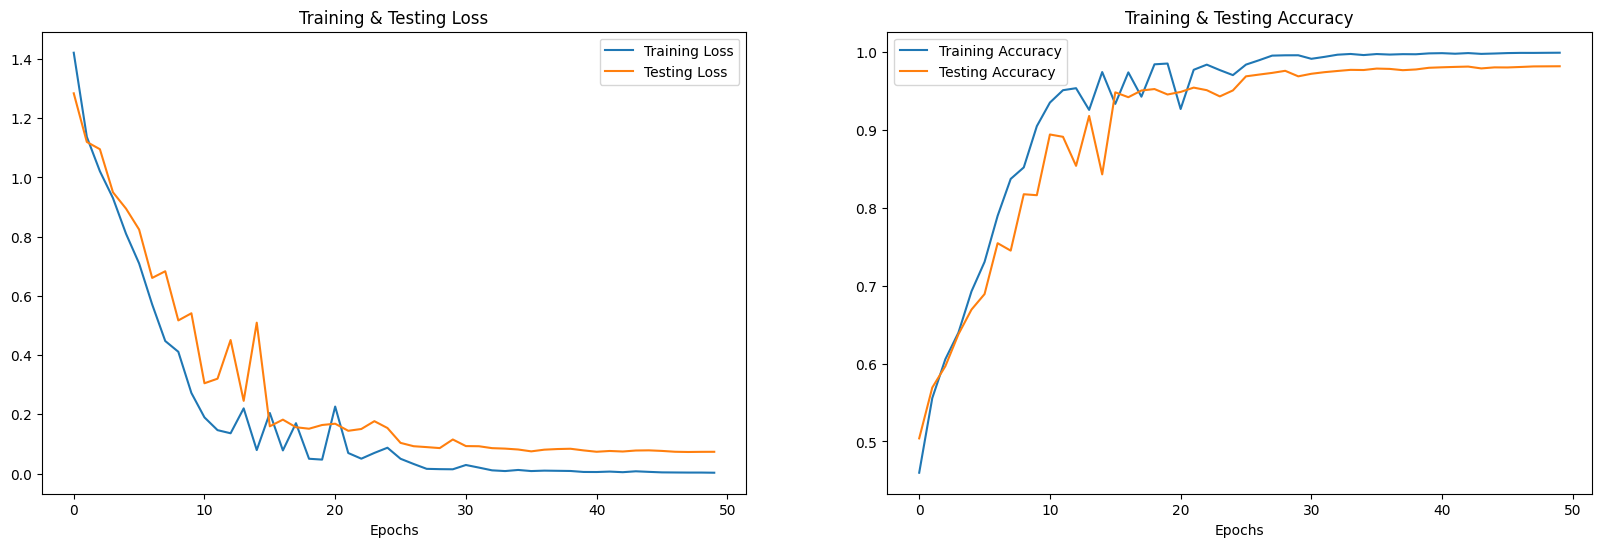

In [ ]:
# Print final test accuracy
print("Test Accuracy: ", cnn_model.evaluate(x_testcnn, y_test)[1] * 100, "%")

epoch_range = range(50)
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

train_acc  = history.history['accuracy']
train_loss = history.history['loss']
val_acc    = history.history['val_accuracy']
val_loss   = history.history['val_loss']

axes[0].plot(epoch_range, train_loss, label='Train Loss')
axes[0].plot(epoch_range, val_loss,   label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epoch_range, train_acc, label='Train Accuracy')
axes[1].plot(epoch_range, val_acc,   label='Validation Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Run inference on the test set
pred_probs = cnn_model.predict(x_testcnn)
y_pred0    = encoder.inverse_transform(pred_probs)
y_test0    = encoder.inverse_transform(y_test)

# Assemble a comparison dataframe
results_df = pd.DataFrame({
    'Predicted Labels': y_pred0.flatten(),
    'Actual Labels':    y_test0.flatten()
})
results_df.head(10)

305/305 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


,Predicted Labels,Actual Labels
0,sad,angry
1,angry,angry
2,disgust,disgust
3,happy,happy
4,fear,fear
5,happy,happy
6,happy,happy
7,fear,fear
8,fear,fear
9,surprise,surprise


In [ ]:
results_df

,Predicted Labels,Actual Labels
0,sad,angry
1,angry,angry
2,disgust,disgust
3,happy,happy
4,fear,fear
...,...,...
9725,fear,fear
9726,disgust,disgust
9727,neutral,neutral
9728,sad,sad


Evaluation
Results of best model

In [ ]:
import seaborn as sns

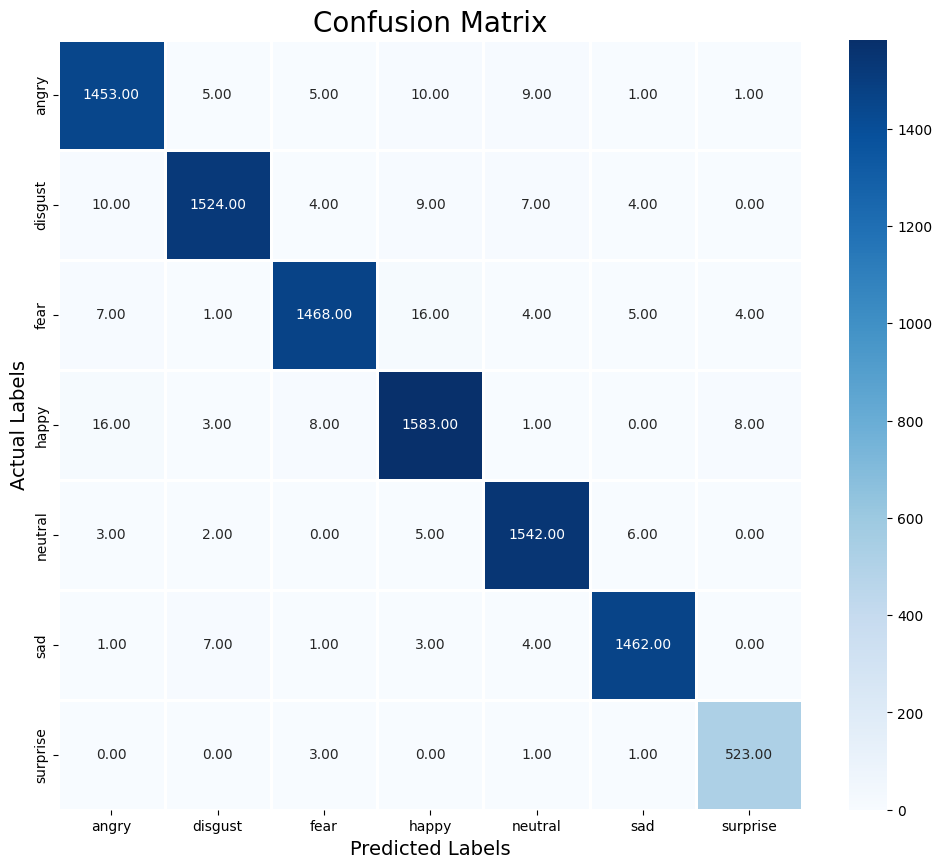

              precision    recall  f1-score   support

       angry       0.98      0.98      0.98      1484
     disgust       0.99      0.98      0.98      1558
        fear       0.99      0.98      0.98      1505
       happy       0.97      0.98      0.98      1619
     neutral       0.98      0.99      0.99      1558
         sad       0.99      0.99      0.99      1478
    surprise       0.98      0.99      0.98       528

    accuracy                           0.98      9730
   macro avg       0.98      0.98      0.98      9730
weighted avg       0.98      0.98      0.98      9730



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Build confusion matrix and render as a heatmap
cm_array = confusion_matrix(y_test0, y_pred0)
cm_df = pd.DataFrame(
    cm_array,
    index=encoder.categories_,
    columns=encoder.categories_
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_df, annot=True, fmt='.2f',
    cmap='Blues', linewidths=1, linecolor='white'
)
plt.title('Confusion Matrix', fontsize=20)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('Actual Labels', fontsize=14)
plt.show()

print(classification_report(y_test0, y_pred0))